In [20]:
import rospy
import actionlib
from geometry_msgs.msg import PoseStamped

from nav_msgs.msg import Odometry 
from sensor_msgs.msg import LaserScan 
from std_msgs.msg import Header

from IPython.display import display
from ipywidgets import IntText, Button, HBox, VBox, Label

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

%matplotlib notebook

import assignment_2_2024.msg

In [21]:
# Initializing the ROS node
if not rospy.core.is_initialized():
    rospy.init_node('jupyter_client_node', anonymous=True)

# Creating the action client
client = actionlib.SimpleActionClient('reaching_goal', assignment_2_2024.msg.PlanningAction)
client.wait_for_server()

current_feedback = None 

robot_position = (0.0, 0.0) 
obstacle_dist = float('inf') 

# Arrays to memorize the trajectory
traj_x = []
traj_y = []

# Adding labels to print status, position and distance from obstacles
status_label = Label(value = "")
position_label = Label(value="Robot position: (0.00, 0.00)")
obstacle_label = Label(value="Closest obstacle: N/A")

In [22]:
# Function for odom acallback
def odom_callback(msg): 
    global robot_position, traj_x, traj_y
    x =  msg.pose.pose.position.x
    y =  msg.pose.pose.position.y
    robot_position = (x, y)

    position_label.value = f"Robot position: ({x:.2f}, {y:.2f})"

    traj_x.append(x)
    traj_y.append(y)

# Function to distance callback
def scan_callback(msg):
    global obstacle_dist
    dist = [d for d in msg.ranges if not rospy.is_shutdown() and msg.range_min < d < msg.range_max]
    if dist:
        obstacle_dist = min(dist)
        obstacle_label.value = f"Closest obstacle: {obstacle_dist:.2f} m"  

# Creating two subscribers to the two topics
rospy.Subscriber("/odom", Odometry, odom_callback)
rospy.Subscriber("/scan", LaserScan, scan_callback) 

In [23]:
# Function to update feedback
def update_feedback(fd): 
    global current_feedback
    current_feedback = fd
    
# Function to set and send the goal
def send_goal(b):
    x = x_input.value
    y = y_input.value

    if(-10.0 < x < 10.0 and -10 < y < 10.0):
        goal = assignment_2_2024.msg.PlanningGoal()
        goal.target_pose = PoseStamped()

        goal.target_pose.header.stamp = rospy.Time.now()
        goal.target_pose.header.frame_id = "odom"
        goal.target_pose.pose.orientation.w = 1.0

        goal.target_pose.pose.position.x = x
        goal.target_pose.pose.position.y = y
                
        client.send_goal(goal, feedback_cb = update_feedback)

        rospy.sleep(0.5)
        state = client.get_state()
        rospy.loginfo(f"Goal status: {state}")

        rospy.loginfo(f"Goal sent: ({x}, {y})")
        status_label.value = f"Goal sent: ({x}, {y})"
        
    else:
        rospy.loginfo("Target out of boundaries")        
        status_label.value = "Target out of boundaries"


# Function to delete the goal
def cancel_goal(b):
    client.cancel_goal()
    rospy.loginfo("Goal cancelled")
    status_label.value = "Goal cancelled"

In [24]:
# Function the cancel button activate 
def cancel_goal_btn(b):
    if client.get_state() not in [actionlib.GoalStatus.SUCCEEDED, actionlib.GoalStatus.ABORTED, actionlib.GoalStatus.PREEMPTED]:
        rospy.loginfo("Cancelling the current goal.")
        client.cancel_goal()
    else:
        rospy.loginfo("The goal has already been achieved.")

# Function the feedback button activate 
def update_feedback_btn(b):
    rospy.loginfo("Requesting feedback...\n")
    if current_feedback is None:
        rospy.loginfo("No feedback has been recieved")
        status_label.value = "No feedback has been recieved"
    else:
        rospy.loginfo(f"Latest feedback:\n {current_feedback}")
        status_label.value = f"Latest feedback:\n {current_feedback}"


In [25]:
# Function to update the robot position graph
def update_graph(frame):
    ax.clear()
    ax.plot(traj_x, traj_y, 'b-', label = 'Trajectory')
    ax.plot(traj_x[-1], traj_y[-1], 'ro', label = 'Current Position')
    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 10)
    ax.set_title('Robot Position in real-time')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
    ax.grid(True)

<IPython.core.display.Javascript object>


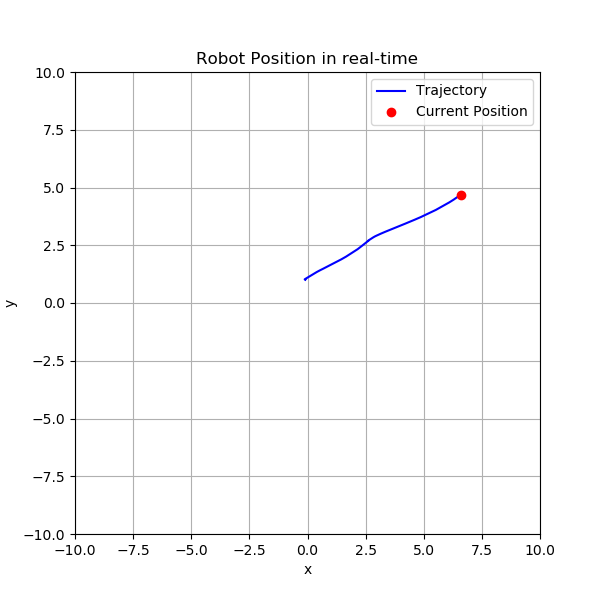

[INFO] [1746548095.879991, 1358.859000]: Goal status: 1
[INFO] [1746548095.888184, 1358.863000]: Goal sent: (3, 3)
[INFO] [1746548136.717136, 1393.292000]: Goal status: 1
[INFO] [1746548136.727425, 1393.316000]: Goal sent: (7, 5)


In [26]:
# UI widgets
x_input = IntText(value = 0, description =  'X: ')
y_input = IntText(value = 0, description =  'Y: ')

send_btn = Button(description = "Send Goal", button_style = 'success')
cancel_btn = Button(description = "Cancel Goal", button_style = 'danger')
feedback_btn = Button(description = "FeedBack")

send_btn.on_click(send_goal)
cancel_btn.on_click(cancel_goal_btn)
feedback_btn.on_click(update_feedback_btn)

# Layout
ui = VBox ([
    HBox([x_input, y_input]),
    HBox([send_btn, cancel_btn]),
    HBox([feedback_btn]),
    status_label,
    position_label,
    obstacle_label
])

display(ui)

fig, ax = plt.subplots(figsize = (6,6))
ani = FuncAnimation(fig, update_graph, interval = 1000)

# display(fig)